
--- Snapshot 1 ---
Random: Nodes=[6, 21, 29, 26, 27], Reduction=2
Degree: Nodes=[4, 22, 10, 13, 20], Reduction=7
Betweenness: Nodes=[15, 22, 25, 8, 5], Reduction=3

--- Snapshot 2 ---
Random: Nodes=[6, 15, 22, 21, 14], Reduction=-3
Degree: Nodes=[4, 22, 12, 13, 20], Reduction=-1
Betweenness: Nodes=[15, 22, 8, 25, 24], Reduction=0

--- Snapshot 3 ---
Random: Nodes=[12, 17, 26, 22, 7], Reduction=-2
Degree: Nodes=[4, 13, 22, 12, 20], Reduction=2
Betweenness: Nodes=[22, 15, 8, 25, 12], Reduction=0

Final Results:
    Snapshot       Method       Critical Nodes  Original Spread  Spread After  \
0         1       Random  [6, 21, 29, 26, 27]                8             6   
1         1       Degree  [4, 22, 10, 13, 20]                8             1   
2         1  Betweenness   [15, 22, 25, 8, 5]                8             5   
3         2       Random  [6, 15, 22, 21, 14]                6             9   
4         2       Degree  [4, 22, 12, 13, 20]                6             7   
5  

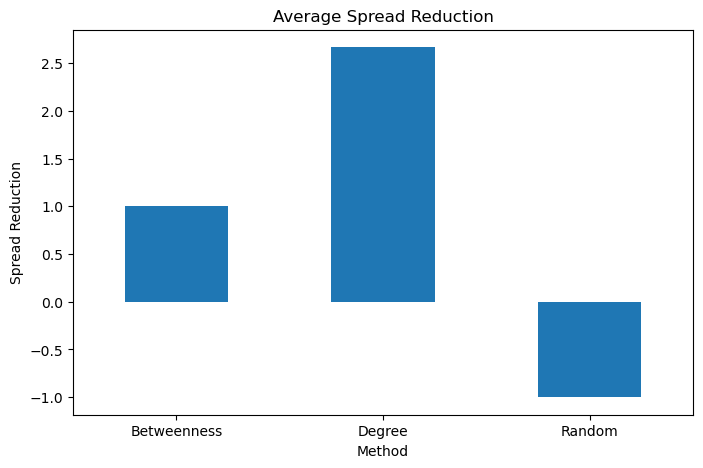

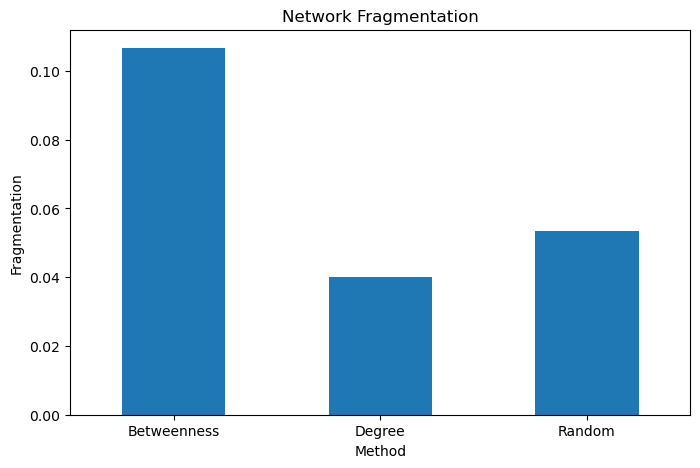

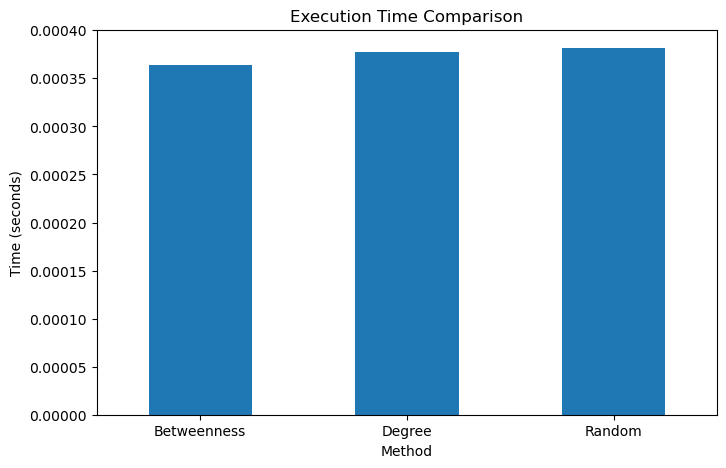

In [1]:
# ===============================
# IMPORT LIBRARIES
# ===============================
import networkx as nx
import random
import time
import matplotlib.pyplot as plt
import pandas as pd


# ===============================
# CREATE TEMPORAL GRAPHS
# ===============================
def create_temporal_graphs():
    graphs = []

    # -------- Snapshot 1 --------
    G1 = nx.Graph()
    G1.add_nodes_from(range(1, 31))

    # Communities
    communities = [range(1, 11), range(11, 21), range(21, 31)]

    for comm in communities:
        for i in comm:
            for j in comm:
                if i < j and random.random() < 0.4:
                    G1.add_edge(i, j)

    # Bridge edges
    G1.add_edges_from([(5, 15), (15, 25), (8, 22), (10, 18), (20, 28)])
    graphs.append(G1)

    # -------- Snapshot 2 --------
    G2 = G1.copy()
    G2.add_edges_from([(3, 12), (14, 24), (7, 17), (19, 27)])
    if G2.has_edge(10, 18):
        G2.remove_edge(10, 18)
    graphs.append(G2)

    # -------- Snapshot 3 --------
    G3 = G2.copy()
    G3.add_edges_from([(2, 23), (9, 26), (13, 29)])
    if G3.has_edge(5, 15):
        G3.remove_edge(5, 15)
    graphs.append(G3)

    return graphs


# ===============================
# CENTRALITY METHODS
# ===============================
def get_top_k_degree(G, k=5):
    degree_scores = nx.degree_centrality(G)
    return sorted(degree_scores, key=degree_scores.get, reverse=True)[:k]


def get_top_k_betweenness(G, k=5):
    nodes = list(G.nodes())
    sample_k = min(10, len(nodes))
    bet_scores = nx.betweenness_centrality(G, k=sample_k, seed=42)
    return sorted(bet_scores, key=bet_scores.get, reverse=True)[:k]


def get_top_k_random(G, k=5):
    return random.sample(list(G.nodes()), k)


# ===============================
# MISINFORMATION SPREAD MODEL
# ===============================
def simulate_misinformation_spread(G, seed_nodes, infection_prob=0.3):
    infected = set(seed_nodes)
    newly_infected = set(seed_nodes)

    while newly_infected:
        next_infected = set()
        for node in newly_infected:
            for neighbor in G.neighbors(node):
                if neighbor not in infected and random.random() < infection_prob:
                    next_infected.add(neighbor)

        newly_infected = next_infected
        infected.update(newly_infected)

    return len(infected)


# ===============================
# STRUCTURAL METRICS
# ===============================
def structural_metrics(G):
    largest_cc = len(max(nx.connected_components(G), key=len))
    num_components = nx.number_connected_components(G)
    fragmentation = num_components / G.number_of_nodes()
    return largest_cc, num_components, fragmentation


# ===============================
# MAIN EXECUTION
# ===============================
graphs = create_temporal_graphs()
results = []

for t, G in enumerate(graphs, start=1):
    print(f"\n--- Snapshot {t} ---")

    # Random seeds for spread
    seed_nodes = random.sample(list(G.nodes()), 2)

    # Original spread
    original_spread = simulate_misinformation_spread(G, seed_nodes)

    methods = {
        "Random": get_top_k_random(G),
        "Degree": get_top_k_degree(G),
        "Betweenness": get_top_k_betweenness(G)
    }

    for method_name, critical_nodes in methods.items():
        start_time = time.time()

        G_modified = G.copy()
        G_modified.remove_nodes_from(critical_nodes)

        exec_time = time.time() - start_time

        # Ensure seed nodes exist after removal
        valid_seeds = [n for n in seed_nodes if n in G_modified.nodes()]

        spread_after = simulate_misinformation_spread(G_modified, valid_seeds)
        spread_reduction = original_spread - spread_after

        largest_cc, num_components, fragmentation = structural_metrics(G_modified)

        results.append({
            "Snapshot": t,
            "Method": method_name,
            "Critical Nodes": critical_nodes,
            "Original Spread": original_spread,
            "Spread After": spread_after,
            "Spread Reduction": spread_reduction,
            "Largest CC": largest_cc,
            "Components": num_components,
            "Fragmentation": fragmentation,
            "Execution Time": exec_time
        })

        print(f"{method_name}: Nodes={critical_nodes}, Reduction={spread_reduction}")


# ===============================
# RESULTS DATAFRAME
# ===============================
df_results = pd.DataFrame(results)
print("\nFinal Results:\n", df_results)


# ===============================
# SUMMARY ANALYSIS
# ===============================
summary = df_results.groupby("Method")[["Spread Reduction", "Fragmentation", "Execution Time"]].mean()

print("\nSummary:\n", summary)


# ===============================
# VISUALIZATION
# ===============================
summary["Spread Reduction"].plot(kind="bar", figsize=(8,5))
plt.title("Average Spread Reduction")
plt.ylabel("Spread Reduction")
plt.xticks(rotation=0)
plt.show()

summary["Fragmentation"].plot(kind="bar", figsize=(8,5))
plt.title("Network Fragmentation")
plt.ylabel("Fragmentation")
plt.xticks(rotation=0)
plt.show()

summary["Execution Time"].plot(kind="bar", figsize=(8,5))
plt.title("Execution Time Comparison")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=0)
plt.show()